In [1]:
!pip install tensorflow opencv-python matplotlib pillow


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

x_train, x_test = x_train / 255.0, x_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 658s 4us/step


In [4]:
IMG_SIZE = 224

x_train = tf.image.resize(x_train, (IMG_SIZE, IMG_SIZE))
x_test = tf.image.resize(x_test, (IMG_SIZE, IMG_SIZE))

In [5]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [6]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
model.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 500s 317ms/step - accuracy: 0.7315 - loss: 0.7743 - val_accuracy: 0.7836 - val_loss: 0.6176
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 501s 317ms/step - accuracy: 0.7830 - loss: 0.6210 - val_accuracy: 0.8050 - val_loss: 0.5584
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 503s 317ms/step - accuracy: 0.7976 - loss: 0.5727 - val_accuracy: 0.7908 - val_loss: 0.6116
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 526s 337ms/step - accuracy: 0.8113 - loss: 0.5410 - val_accuracy: 0.8116 - val_loss: 0.5367
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 555s 332ms/step - accuracy: 0.8176 - loss: 0.5154 - val_accuracy: 0.8128 - val_loss: 0.5296


In [9]:
model.save("cifar10_model.h5")

In [10]:
def predict_image(image_path):
    img = cv2.imread(image_path)
    img_resized = cv2.resize(img, (224, 224))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    prediction = model.predict(img_input)
    class_index = np.argmax(prediction)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Prediction: {class_names[class_index]}")
    plt.axis('off')
    plt.show()

    print("Predicted Class:", class_names[class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


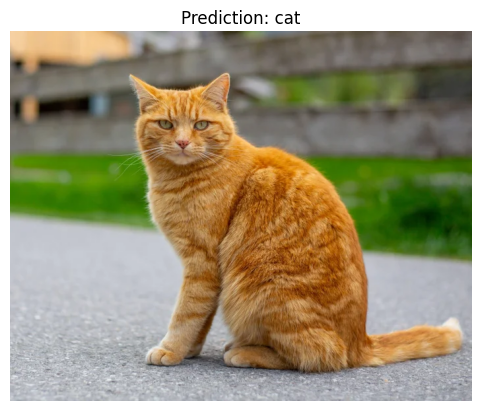

Predicted Class: cat


In [11]:
predict_image(r"Z:\testcat.webp")

In [ ]:
predict_image(r"Z:\testcat.webp")